In [1]:
# ============================================================
# CELL 1: CONFIG
# ============================================================
import os, time, json
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, confusion_matrix, classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

print("CUDA available:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

DATA_DIR = "Medicinal Plant Leaf Health Split Dataset"
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 30
LR = 1e-3

RUN_TAG = "custom_cnn_full"
SAVE_DIR = os.path.join("checkpoints", RUN_TAG)
os.makedirs(SAVE_DIR, exist_ok=True)
CKPT_PATH = os.path.join(SAVE_DIR, "last_checkpoint.pth")
BEST_PATH = os.path.join(SAVE_DIR, "best_model.pth")
RESULTS_PATH = os.path.join(SAVE_DIR, "results.json")
CURVES_PATH = os.path.join(SAVE_DIR, "curves.png")
HISTORY_PATH = os.path.join(SAVE_DIR, "history.json")

CUDA available: True
Using device: cuda


In [2]:
# ============================================================
# CELL 2: TRANSFORMS
# ============================================================
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [3]:
# ============================================================
# CELL 3: LOAD DATA
# ============================================================
train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_tf)
val_ds   = datasets.ImageFolder(os.path.join(DATA_DIR, "val"), transform=eval_tf)
test_ds  = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

NUM_CLASSES = len(train_ds.classes)
class_names = train_ds.classes
print(f"Classes ({NUM_CLASSES}): {class_names}")
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

assert train_ds.classes == val_ds.classes == test_ds.classes, "Class mismatch across splits!"

Classes (16): ['Aloe Vera Disease', 'Aloe Vera Dried', 'Aloe Vera Mature Healthy', 'Aloe Vera Young Healthy', 'Azadirachta Indica Chlorotic', 'Azadirachta Indica Disease', 'Azadirachta Indica Healthy', 'Hibiscus Rosa Sinensis Chlorotic', 'Hibiscus Rosa Sinensis Disease', 'Hibiscus Rosa Sinensis Healthy', 'Kalanchoe Pinnata Chlorotic', 'Kalanchoe Pinnata Disease', 'Kalanchoe Pinnata Healthy', 'Piper Betle Chlorotic', 'Piper Betle Disease', 'Piper Betle Healthy']
Train: 924 | Val: 199 | Test: 200


In [4]:
# ============================================================
# CELL 4: CLASS WEIGHTS
# ============================================================
class_counts = np.bincount([label for _, label in train_ds.samples])
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print("Class weights:", class_weights.cpu().numpy())

Class weights: [1.0930157  1.2201105  1.279628   1.3116188  0.6321054  0.6030431
 0.49032477 1.0089375  1.1405381  1.0492951  1.279628   1.0287206
 1.4573542  0.6903257  0.79492044 0.92043424]


In [5]:
# ============================================================
# CELL 5: CUSTOM LIGHTWEIGHT CNN (32 -> 64 -> 128) — unchanged
# ============================================================
class LightCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

model = LightCNN(NUM_CLASSES).to(DEVICE)
num_params = sum(p.numel() for p in model.parameters())
print(f"Total params: {num_params:,} (~{num_params/1e6:.3f}M)")

Total params: 95,760 (~0.096M)


In [6]:
# ============================================================
# CELL 6: LOSS / OPTIMIZER — UPDATED (lower LR, weight decay, cosine schedule)
# ============================================================
LR = 3e-4                 # lowered from 1e-3
WEIGHT_DECAY = 1e-4        # added regularization
GRAD_CLIP_NORM = 1.0       # added gradient clipping

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)  # replaces ReduceLROnPlateau

In [7]:
# ============================================================
# CELL 7: EPOCH RUNNER — UPDATED (gradient clipping added)
# ============================================================
def run_epoch(loader, train=True, desc="Epoch"):
    model.train() if train else model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    context = torch.enable_grad() if train else torch.no_grad()
    pbar = tqdm(loader, desc=desc, leave=False)
    with context:
        for imgs, labels in pbar:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if train:
                optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)  # NEW
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, acc, macro_f1, precision, recall

In [8]:
# ============================================================
# CELL 8: CHECKPOINT RESUME
# ============================================================
start_epoch = 1
best_val_f1 = 0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "train_f1": [], "val_f1": []}

if os.path.exists(CKPT_PATH):
    print(f"Resuming from checkpoint: {CKPT_PATH}")
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt["scheduler_state"])
    start_epoch = ckpt["epoch"] + 1
    best_val_f1 = ckpt["best_val_f1"]
    if os.path.exists(HISTORY_PATH):
        with open(HISTORY_PATH) as f:
            history = json.load(f)
    print(f"Resumed at epoch {start_epoch}, best_val_f1={best_val_f1:.4f}")

In [9]:
# ============================================================
# CELL 9 (part): TRAINING LOOP — UPDATED scheduler.step() call
# ============================================================
for epoch in range(start_epoch, EPOCHS + 1):
    train_loss, train_acc, train_f1, _, _ = run_epoch(train_loader, train=True, desc=f"Epoch {epoch}/{EPOCHS} [train]")
    val_loss, val_acc, val_f1, val_prec, val_rec = run_epoch(val_loader, train=False, desc=f"Epoch {epoch}/{EPOCHS} [val]")
    scheduler.step()   # CosineAnnealingLR steps every epoch unconditionally (no metric argument needed)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    print(f"[{RUN_TAG}] Epoch {epoch}/{EPOCHS} | "
          f"Train loss {train_loss:.4f} acc {train_acc:.4f} f1 {train_f1:.4f} | "
          f"Val loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f} | "
          f"LR {optimizer.param_groups[0]['lr']:.6f}", flush=True)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), BEST_PATH)
        print(f"  -> New best model saved (val macro-F1={val_f1:.4f})", flush=True)

    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "best_val_f1": best_val_f1,
    }, CKPT_PATH)

    with open(HISTORY_PATH, "w") as f:
        json.dump(history, f, indent=2)

[custom_cnn_full] Epoch 1/30 | Train loss 2.5458 acc 0.1764 f1 0.1442 | Val loss 2.4990 acc 0.2362 f1 0.1838 | LR 0.000299
  -> New best model saved (val macro-F1=0.1838)


[custom_cnn_full] Epoch 2/30 | Train loss 2.2585 acc 0.2944 f1 0.2641 | Val loss 2.1477 acc 0.3769 f1 0.3474 | LR 0.000297
  -> New best model saved (val macro-F1=0.3474)


[custom_cnn_full] Epoch 3/30 | Train loss 2.1138 acc 0.3734 f1 0.3359 | Val loss 2.0113 acc 0.4925 f1 0.4509 | LR 0.000293
  -> New best model saved (val macro-F1=0.4509)


[custom_cnn_full] Epoch 4/30 | Train loss 2.0286 acc 0.3842 f1 0.3508 | Val loss 2.0504 acc 0.2814 f1 0.2375 | LR 0.000287


[custom_cnn_full] Epoch 5/30 | Train loss 1.9311 acc 0.4275 f1 0.3970 | Val loss 1.9804 acc 0.2965 f1 0.2692 | LR 0.000280


...

[custom_cnn_full] Epoch 26/30 | Train loss 1.3368 acc 0.6656 f1 0.6457 | Val loss 1.3078 acc 0.7739 f1 0.7560 | LR 0.000013


[custom_cnn_full] Epoch 27/30 | Train loss 1.3760 acc 0.6385 f1 0.6172 | Val loss 1.3039 acc 0.7588 f1 0.7474 | LR 0.000007


[custom_cnn_full] Epoch 28/30 | Train loss 1.3734 acc 0.6764 f1 0.6570 | Val loss 1.3132 acc 0.7638 f1 0.7579 | LR 0.000003


[custom_cnn_full] Epoch 29/30 | Train loss 1.3509 acc 0.6688 f1 0.6436 | Val loss 1.3033 acc 0.7739 f1 0.7616 | LR 0.000001


[custom_cnn_full] Epoch 30/30 | Train loss 1.3851 acc 0.6494 f1 0.6290 | Val loss 1.3186 acc 0.7839 f1 0.7747 | LR 0.000000
  -> New best model saved (val macro-F1=0.7747)


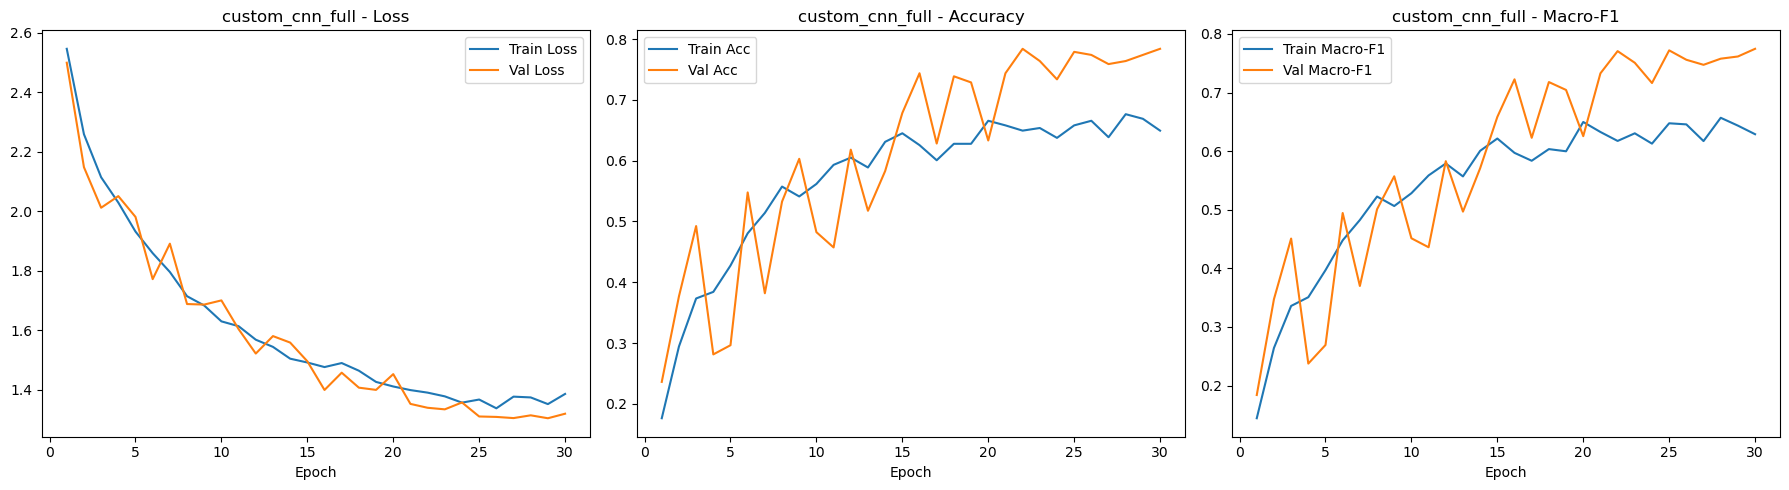

In [10]:
# ============================================================
# CELL 10: PLOT CURVES
# ============================================================
epochs_range = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss")
axes[0].set_title(f"{RUN_TAG} - Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="Train Acc")
axes[1].plot(epochs_range, history["val_acc"], label="Val Acc")
axes[1].set_title(f"{RUN_TAG} - Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()

axes[2].plot(epochs_range, history["train_f1"], label="Train Macro-F1")
axes[2].plot(epochs_range, history["val_f1"], label="Val Macro-F1")
axes[2].set_title(f"{RUN_TAG} - Macro-F1"); axes[2].set_xlabel("Epoch"); axes[2].legend()

plt.tight_layout()
plt.savefig(CURVES_PATH, dpi=300)
plt.show()

/tmp/ipykernel_9888/4172477332.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(BEST_PATH))
                                             


=== FINAL TEST RESULTS ===
{
  "model": "custom_cnn",
  "train_mode": "full",
  "test_accuracy": 0.81,
  "test_macro_f1": 0.7637001666070602,
  "test_precision": 0.7973663174350514,
  "test_recall": 0.8021251921387791,
  "total_params": 95760,
  "trainable_params": 95760,
  "model_size_mb": 0.365,
  "inference_ms_per_image": 0.017,
  "best_val_macro_f1": 0.7747249508871868
}


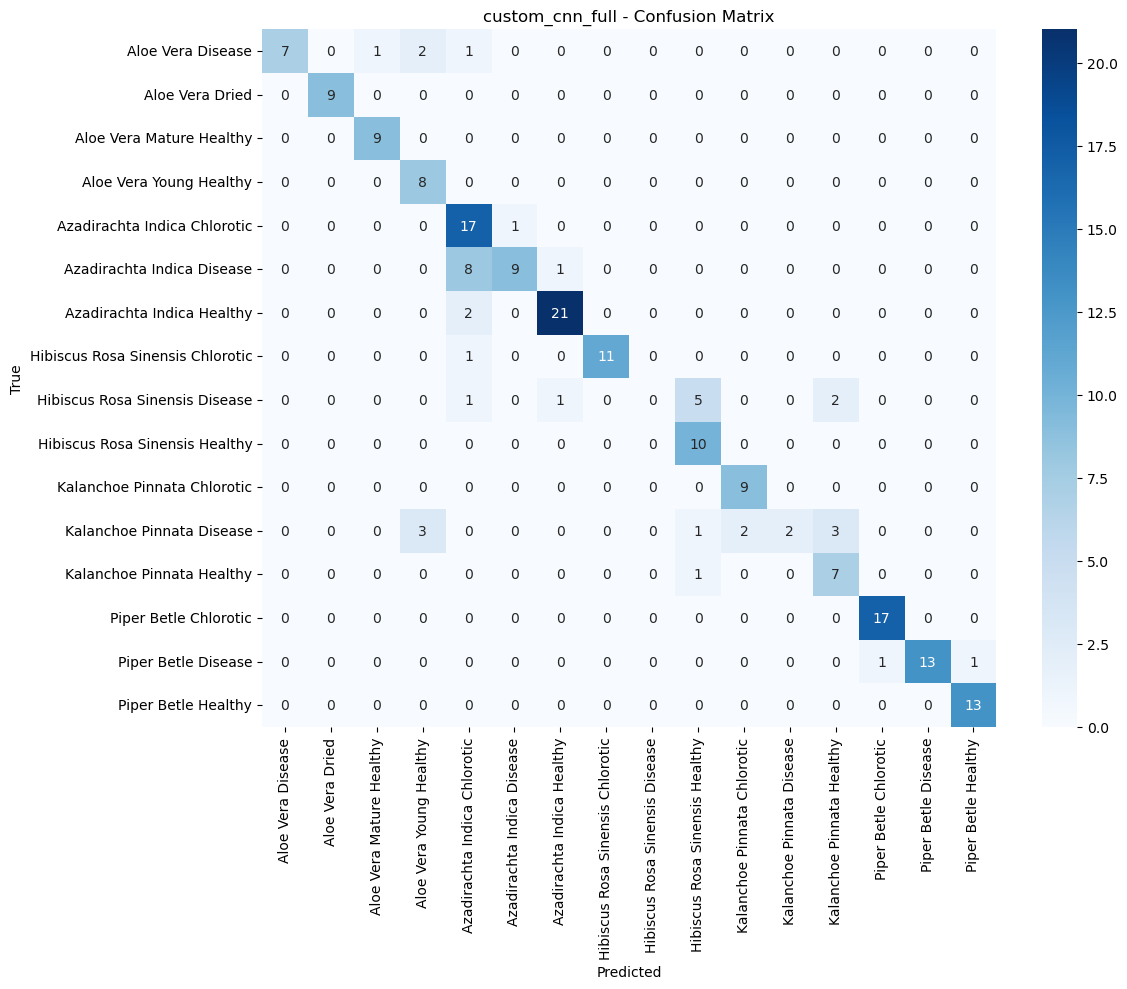

                                  precision  recall  f1-score  support
Aloe Vera Disease                    1.0000  0.6364    0.7778    11.00
Aloe Vera Dried                      1.0000  1.0000    1.0000     9.00
Aloe Vera Mature Healthy             0.9000  1.0000    0.9474     9.00
Aloe Vera Young Healthy              0.6154  1.0000    0.7619     8.00
Azadirachta Indica Chlorotic         0.5667  0.9444    0.7083    18.00
Azadirachta Indica Disease           0.9000  0.5000    0.6429    18.00
Azadirachta Indica Healthy           0.9130  0.9130    0.9130    23.00
Hibiscus Rosa Sinensis Chlorotic     1.0000  0.9167    0.9565    12.00
Hibiscus Rosa Sinensis Disease       0.0000  0.0000    0.0000     9.00
Hibiscus Rosa Sinensis Healthy       0.5882  1.0000    0.7407    10.00
Kalanchoe Pinnata Chlorotic          0.8182  1.0000    0.9000     9.00
Kalanchoe Pinnata Disease            1.0000  0.1818    0.3077    11.00
Kalanchoe Pinnata Healthy            0.5833  0.8750    0.7000     8.00
Piper 

In [11]:
# ============================================================
# CELL 11: FINAL TEST EVAL + CONFUSION MATRIX + PER-CLASS REPORT
# ============================================================
model.load_state_dict(torch.load(BEST_PATH))
model.eval()

# inference speed
sample_batch, _ = next(iter(test_loader))
sample_batch = sample_batch.to(DEVICE)
with torch.no_grad():
    start = time.time()
    for _ in range(20):
        _ = model(sample_batch)
    elapsed = time.time() - start
per_image_ms = (elapsed / (20 * sample_batch.size(0))) * 1000

test_loss, test_acc, test_f1, test_prec, test_rec = run_epoch(test_loader, train=False, desc="Final Test")

num_params = sum(p.numel() for p in model.parameters())
model_size_mb = num_params * 4 / (1024 ** 2)

results = {
    "model": "custom_cnn", "train_mode": "full",
    "test_accuracy": test_acc, "test_macro_f1": test_f1,
    "test_precision": test_prec, "test_recall": test_rec,
    "total_params": num_params, "trainable_params": num_params,
    "model_size_mb": round(model_size_mb, 3),
    "inference_ms_per_image": round(per_image_ms, 3),
    "best_val_macro_f1": best_val_f1,
}
print("\n=== FINAL TEST RESULTS ===")
print(json.dumps(results, indent=2))
with open(RESULTS_PATH, "w") as f:
    json.dump(results, f, indent=2)

# collect predictions for confusion matrix / per-class report / prediction log
all_preds, all_labels = [], []
test_samples = test_ds.samples
prediction_log = []
idx = 0
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)
        confidences = probs.max(dim=1).values
        for i in range(imgs.size(0)):
            filepath, true_idx = test_samples[idx]
            pred_idx = preds[i].item()
            all_preds.append(pred_idx)
            all_labels.append(true_idx)
            prediction_log.append({
                "image_path": filepath,
                "true_class": class_names[true_idx],
                "predicted_class": class_names[pred_idx],
                "confidence": round(confidences[i].item(), 4),
                "correct": true_idx == pred_idx,
            })
            idx += 1

pred_log_df = pd.DataFrame(prediction_log)
pred_log_df.to_csv(os.path.join(SAVE_DIR, "test_predictions_log.csv"), index=False)

# confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title(f"{RUN_TAG} - Confusion Matrix")
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "confusion_matrix.png"), dpi=300)
plt.show()

# per-class report
report_dict = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).transpose().round(4)
report_df.to_csv(os.path.join(SAVE_DIR, "per_class_report.csv"))
print(report_df)

print(f"\nAll outputs saved to {SAVE_DIR}")